# 2장 4강: 이벤트 로그 기반 AARRR 퍼널 집계 및 시각화 — 실습문제

## 실습 목표

- 계정·구독·기능 사용 데이터를 연결하여 퍼널 단계 도달 기록을 만들 수 있다.
- `groupby()`와 `nunique()`로 단계별 고유 계정 수를 집계할 수 있다.
- 전 단계 대비 전환율과 최초 단계 대비 전체 전환율을 계산할 수 있다.
- 퍼널을 가로 막대그래프로 시각화하고 이탈 집중 구간을 찾을 수 있다.
- 수치에서 확인한 이탈 구간을 바탕으로 개선 가설과 검증 방법을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_accounts.csv`
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습에서는 다음 네 단계를 누적 퍼널로 정의합니다.

| 단계 | 도달 조건 |
|---|---|
| Acquisition | 관찰 종료일보다 30일 이상 앞서 가입한 계정 |
| Activation | 가입 후 30일 이내 첫 구독을 시작한 계정 |
| Retention | Activation 계정 중 첫 구독 시작 30일 후에도 유효한 기능 사용 기록이 있는 계정 |
| Revenue | Retention 계정 중 첫 구독이 체험판이 아니고 `mrr_amount > 0`인 계정 |

> Ravenstack 데이터에는 다른 사용자를 추천한 행동을 뜻하는 Referral 이벤트가 없습니다. `referral_source`는 **현재 계정이 유입된 경로**이므로 Referral 행동으로 잘못 사용하지 않고, 이번 실습에서는 측정 가능한 Acquisition~Revenue 4단계만 분석합니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 세 CSV 파일을 각각 `accounts`, `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치를 확인하세요.
5. 날짜 컬럼을 날짜형으로 변환하세요.
6. 계정별 가장 이른 구독을 `first_subscription`으로 만드세요.
7. 기능 사용 기록에 첫 구독 정보를 결합하고, 구독 시작 전 또는 종료 후 기록을 제외한 `valid_usage`를 만드세요.
8. 기능 사용 데이터의 마지막 날짜에서 30일을 뺀 날짜를 `observation_cutoff`으로 정하세요.

> 가입 직후 30일이 지나지 않은 계정은 Retention 도달 기회가 부족하므로 분석 대상에서 제외합니다.

In [1]:
# 실습 준비 코드를 작성하세요.
import pandas as pd
import matplotlib.pyplot as plt

accounts = pd.read_csv("C:/Users/jihun/OneDrive/Desktop/DS 실습자료/LV2/프로덕트분석/DATA/1,2,4장/ravenstack_accounts.csv")
subscriptions = pd.read_csv("C:/Users/jihun/OneDrive/Desktop/DS 실습자료/LV2/프로덕트분석/DATA/1,2,4장/ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("C:/Users/jihun/OneDrive/Desktop/DS 실습자료/LV2/프로덕트분석/DATA/1,2,4장/ravenstack_feature_usage.csv")

print(f"accounts 크기: {accounts.shape[0]}행, {accounts.shape[1]}열")
print(f"subscriptions 크기: {subscriptions.shape[0]}행, {subscriptions.shape[1]}열")
print(f"feature_usage 크기: {feature_usage.shape[0]}행, {feature_usage.shape[1]}열")

display(accounts.head())
display(subscriptions.head())
display(feature_usage.head())

accounts["signup_date"] = pd.to_datetime(accounts["signup_date"])
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])
feature_usage["usage_date"] = pd.to_datetime(feature_usage["usage_date"])

print("\n[분석 대상 컬럼 결측치]")
print(accounts[["account_id", "signup_date"]].isna().sum())
print(subscriptions[[
    "subscription_id", "account_id", "start_date", "end_date",
    "plan_tier", "is_trial", "mrr_amount"
]].isna().sum())
print(feature_usage[["subscription_id", "usage_date"]].isna().sum())

first_subscription = (subscriptions.sort_values(["account_id", "start_date", "subscription_id"]).drop_duplicates("account_id")
    [["account_id", "subscription_id", "start_date", "end_date","plan_tier", "is_trial", "mrr_amount"]])

usage_with_first_sub = feature_usage.merge(
    first_subscription[[
        "account_id", "subscription_id", "start_date", "end_date"]], on="subscription_id", how="inner")

before_start = usage_with_first_sub["usage_date"] < usage_with_first_sub["start_date"]
after_end = (usage_with_first_sub["end_date"].notna()
    & (usage_with_first_sub["usage_date"] > usage_with_first_sub["end_date"]))

valid_usage = usage_with_first_sub.loc[
    (usage_with_first_sub["usage_count"] > 0) & ~before_start & ~after_end].copy()

observation_end = feature_usage["usage_date"].max()
observation_cutoff = observation_end - pd.Timedelta(days=30)

print(f"\n첫 구독과 연결된 기능 사용 기록: {len(usage_with_first_sub):,}건")
print(f"구독 시작 전 기록: {before_start.sum():,}건")
print(f"구독 종료 후 기록: {after_end.sum():,}건")
print(f"유효 기능 사용 기록: {len(valid_usage):,}건")
print(f"관찰 종료일: {observation_end.date()}")
print(f"가입일 분석 기준: {observation_cutoff.date()} 이전")

accounts 크기: 500행, 10열
subscriptions 크기: 5000행, 14열
feature_usage 크기: 25000행, 8열


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False



[분석 대상 컬럼 결측치]
account_id     0
signup_date    0
dtype: int64
subscription_id       0
account_id            0
start_date            0
end_date           4514
plan_tier             0
is_trial              0
mrr_amount            0
dtype: int64
subscription_id    0
usage_date         0
dtype: int64

첫 구독과 연결된 기능 사용 기록: 2,472건
구독 시작 전 기록: 1,467건
구독 종료 후 기록: 47건
유효 기능 사용 기록: 958건
관찰 종료일: 2024-12-31
가입일 분석 기준: 2024-12-01 이전


C:\Users\jihun\AppData\Local\Temp\ipykernel_84092\3392837529.py:45: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  observation_cutoff = observation_end - pd.Timedelta(days=30)


---

## 필수 1. AARR 단계별 고유 계정 수와 전환율 계산하기

### 문제 1-1. 가입한 계정은 활성화·유지·유료 단계까지 얼마나 도달하는가?

#### 문제 해결 방향

각 단계의 조건을 만족하는 계정 ID를 만들고, 앞 단계에 도달한 계정만 다음 단계에 포함되도록 누적 조건을 적용하세요. 그다음 긴 형태의 `funnel_log`를 만들어 강의에서 배운 `groupby()`와 `nunique()`로 집계합니다.

#### 요구사항

1. `signup_date <= observation_cutoff`인 계정을 `funnel_base`로 만드세요.
2. Acquisition, Activation, Retention, Revenue 도달 여부를 불리언 컬럼으로 만드세요.
3. 단계별 도달 계정만 모아 `account_id`, `stage`로 구성된 `funnel_log`를 만드세요.
4. `groupby("stage")["account_id"].nunique()`로 고유 계정 수를 집계하세요.
5. `reindex()`를 사용해 `Acquisition → Activation → Retention → Revenue` 순서로 정렬하세요.
6. `calc_conversion_rates()` 함수를 작성하여 전 단계 대비 전환율과 전체 대비 전환율을 계산하세요.
7. 단계별 고유 계정 수와 두 전환율을 하나의 `funnel_summary`로 출력하세요.

#### 해석 질문

**Q1.** 이벤트 발생 횟수 대신 고유 계정 수를 사용하는 이유는 무엇인가요?
-> 한 계정이 같은 기능을 여러 번 사용해도 고객은 한 계정(중복 X)

**Q2.** 첫 단계의 전 단계 대비 전환율을 100%로 설정하는 이유는 무엇인가요?
-> Acquisition 앞에는 비교할 단계가 없음, 이 단계가 퍼널 기준의 모집단임.

**Q3.** Retention 단계에 이전 단계 조건을 함께 적용해야 하는 이유는 무엇인가요?  
-> Activation을 거치지 않은 계정이 Retention에 포함되면 서로 다른 모집단을 사용하여
-> 전체적인 숫자가 맞지 않을 수 있다.

**Q4.** 전 단계 대비 전환율과 전체 대비 전환율은 무엇이 다른가요?
-> 전 단계 대비 전환율은 바로 직전 단계에서 다음 단계로 넘어온 비율
-> 전체 대비 전환율은 Acquisition(유입) 계정 중 현재 단계까지 남은 비율

#### 제출 결과

- `funnel_base`와 `funnel_log`
- `calc_conversion_rates()` 함수
- `funnel_summary`
- Q1~Q4 답변

In [ ]:
# 필수 1 코드를 작성하세요.
funnel_base = (
    accounts.loc[
        accounts["signup_date"] <= observation_cutoff,
        ["account_id", "signup_date", "industry"]
    ]
    .merge(first_subscription, on="account_id", how="left")
)

retained_account_ids = set(
    valid_usage.loc[
        valid_usage["usage_date"]
        >= valid_usage["start_date"] + pd.Timedelta(days=30),
        "account_id"
    ]
)

funnel_base["Acquisition"] = True
funnel_base["Activation"] = (
    (funnel_base["start_date"] >= funnel_base["signup_date"])
    & (funnel_base["start_date"] <= funnel_base["signup_date"] + pd.Timedelta(days=30))
)
funnel_base["Retention"] = (
    funnel_base["Activation"]
    & funnel_base["account_id"].isin(retained_account_ids)
)
funnel_base["Revenue"] = (
    funnel_base["Retention"]
    & funnel_base["is_trial"].eq(False)
    & (funnel_base["mrr_amount"] > 0)
)

funnel_stages = ["Acquisition", "Activation", "Retention", "Revenue"]

funnel_log = pd.concat(
    [
        funnel_base.loc[funnel_base[stage], ["account_id"]]
        .assign(stage=stage)
        for stage in funnel_stages
    ],
    ignore_index=True
)

funnel_counts = (
    funnel_log.groupby("stage")["account_id"]
    .nunique()
    .reindex(funnel_stages)
    .fillna(0)
    .astype(int))

def calc_conversion_rates(counts):
    step_conversion = (counts / counts.shift(1) * 100).round(1)
    step_conversion.iloc[0] = 100.0
    overall_conversion = (counts / counts.iloc[0] * 100).round(1)
    return step_conversion, overall_conversion

step_conversion, overall_conversion = calc_conversion_rates(funnel_counts)

funnel_summary = pd.DataFrame({
    "accounts": funnel_counts,
    "step_conversion_pct": step_conversion,
    "overall_conversion_pct": overall_conversion})

print(funnel_summary)

             accounts  step_conversion_pct  overall_conversion_pct
stage                                                             
Acquisition       483                100.0                   100.0
Activation        321                 66.5                    66.5
Retention         207                 64.5                    42.9
Revenue           177                 85.5                    36.6


C:\Users\jihun\AppData\Local\Temp\ipykernel_84092\3198547859.py:13: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  >= valid_usage["start_date"] + pd.Timedelta(days=30),
C:\Users\jihun\AppData\Local\Temp\ipykernel_84092\3198547859.py:21: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  & (funnel_base["start_date"] <= funnel_base["signup_date"] + pd.Timedelta(days=30))


### 필수 1 답변 작성란

- Acquisition : 유입, 483개, 전체 500개중 2024년 12월 1일까지 가입한 계정
- Activation : 활성화, 위 483건 중 가입일로부터 30일 이내에 첫 활동(구독)을 시작한 계정
- Retention : 유지, 207개, Activation에 포함, 첫 구독 시작일부터 30일이 지난 시점에서도 유효한 기능 사용 기록이 있는 계정
- Revenue : 수익, 177개, Retention에 포함되면서 체험판이 아니라 실제 구독료를 낸 계정

---

## 필수 2. 퍼널 시각화와 이탈 구간 개선 가설 만들기

### 문제 2-1. 가장 먼저 개선해야 할 구간은 어디인가?

#### 요구사항

1. 필수 1의 `funnel_summary`를 사용하세요.
2. `barh()`로 단계별 고유 계정 수를 가로 막대그래프로 표시하세요.
3. 막대 옆에 `계정 수 (전 단계 대비 전환율)`을 표시하세요.
4. 첫 단계를 제외하고 전 단계 대비 전환율이 가장 낮은 단계를 찾으세요.
5. 해당 단계와 바로 이전 단계를 이용해 전환율이 가장 낮은 구간을 출력하세요.
6. 이탈 원인 가설 2개와 각 가설의 검증 방법을 제안하세요.

#### 해석 질문

**Q1.** 전 단계 대비 전환율이 가장 낮은 단계와 이탈 구간은 어디인가요?
-> Retention 단계가 64.5%로 가장 낮음, 이탈 구간은 Activaition -> Retention

**Q2.** 퍼널 결과만으로 이탈의 원인을 확정할 수 있나요?  
-> 없다. 퍼널은 계정이 많이 줄어든 구간을 보여준다.
-> 기능, 오류, 지원 등에 대한 원인은 추가적인 데이터 분석을 통해 확인할 수 있다.

**Q3.** 해당 구간을 개선하기 위해 어떤 데이터를 추가로 확인할 수 있나요?
-> 오류 수, 오류 종류, 고객 지원, 프로모션 등을 확인할 수 있다.

#### 제출 결과

- 전환율을 표시한 퍼널 그래프
- 가장 낮은 전환 단계와 이탈 구간
- 개선 가설 2개와 검증 방법
- Q1~Q3 답변

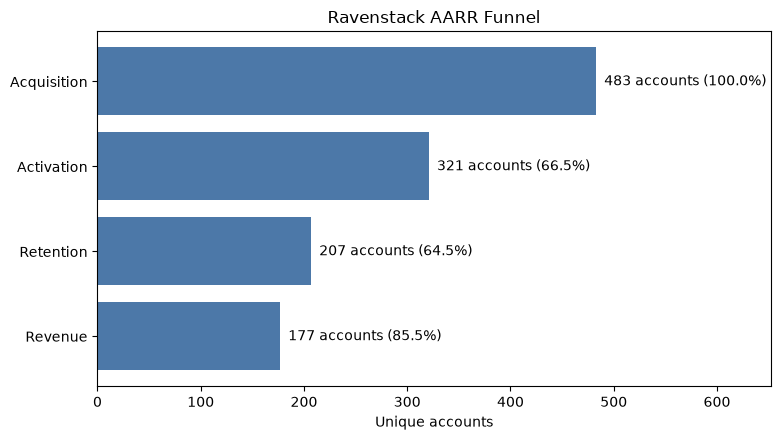

가장 낮은 전환 단계: Retention (64.5%)
이탈 집중 구간: Activation → Retention
해당 구간 이탈 계정 수: 114개

가설 1: 첫 구독 후 핵심 기능의 사용 방법을 충분히 익히지 못했을 수 있습니다.
검증 1: 첫 30일의 기능별 사용 횟수와 온보딩 완료율을 비교합니다.
가설 2: 오류 또는 지원 지연 때문에 지속 사용을 중단했을 수 있습니다.
검증 2: 오류 수와 지원 티켓 경험에 따른 Retention 전환율을 비교합니다.


In [3]:
# 필수 2 코드를 작성하세요.
plot_summary = funnel_summary.iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_summary.index, plot_summary["accounts"], color="#4C78A8")

for i, (_, row) in enumerate(plot_summary.iterrows()):
    ax.text(row["accounts"],
        i, f"  {int(row['accounts']):,} accounts ({row['step_conversion_pct']:.1f}%)", va="center")

ax.set_xlim(0, funnel_summary["accounts"].max() * 1.35)
ax.set_xlabel("Unique accounts")
ax.set_title("Ravenstack AARR Funnel")
plt.tight_layout()
plt.show()

lowest_stage = step_conversion.iloc[1:].idxmin()
lowest_position = funnel_stages.index(lowest_stage)
previous_stage = funnel_stages[lowest_position - 1]
lost_accounts = funnel_counts[previous_stage] - funnel_counts[lowest_stage]

print(f"가장 낮은 전환 단계: {lowest_stage} ({step_conversion[lowest_stage]:.1f}%)")
print(f"이탈 집중 구간: {previous_stage} → {lowest_stage}")
print(f"해당 구간 이탈 계정 수: {lost_accounts:,}개")
print("\n가설 1: 첫 구독 후 핵심 기능의 사용 방법을 충분히 익히지 못했을 수 있습니다.")
print("검증 1: 첫 30일의 기능별 사용 횟수와 온보딩 완료율을 비교합니다.")
print("가설 2: 오류 또는 지원 지연 때문에 지속 사용을 중단했을 수 있습니다.")
print("검증 2: 오류 수와 지원 티켓 경험에 따른 Retention 전환율을 비교합니다.")

### 필수 2 답변 작성란

- **Q1.**
- **Q2.**
- **Q3.**

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 첫 구독 요금제별 퍼널 비교와 개선 가설 제안하기

#### 문제 설명

첫 구독의 plan_tier별로 Acquisition → Activation → Retention → Revenue 단계의 계정 수와 전환율을 비교하세요. 이탈이 집중된 구간을 찾고, 개선 가설과 검증 방법을 제안하세요.

> 필수 문제의 단계 정의와 집계·전환율 계산·시각화 절차를 그대로 활용합니다. Referral은 관련 행동 기록이 없어 분석에서 제외합니다.

#### 요구사항

1. 원시 계정·구독·기능 사용 데이터를 연결하여 funnel_base와 단계 도달 여부를 만드는 코드를 제출물에 포함하세요. 필수 문제에서 작성한 코드를 재사용해도 됩니다.
2. 첫 구독의 plan_tier별로 Acquisition, Activation, Retention, Revenue의 고유 계정 수를 집계하세요. 각 단계에는 이전 단계에 도달한 계정만 포함하세요.
3. 요금제별로 다음 값을 계산하여 plan_funnel을 만드세요.
- 구간 전환율 = 현재 단계 계정 수 ÷ 이전 단계 계정 수 × 100
- 구간 이탈률 = 100 − 구간 전환율
- 구간 이탈 계정 수 = 이전 단계 계정 수 − 현재 단계 계정 수
- 첫 단계는 비교할 이전 단계가 없으므로 구간 지표를 빈 값으로 두세요. 이전 단계 계정 수가 0이면 전환율·이탈률을 계산 불가로 표시하세요.
4. 요금제별로 단계별 고유 계정 수를 가로 막대그래프로 시각화하고, 각 단계의 구간 전환율을 함께 표시하세요.
5. 첫 단계를 제외하고 전환율이 가장 낮은 요금제·구간 조합을 찾으세요. 해당 구간의 전환율·이탈률·이탈 계정 수를 근거로 이탈 집중 구간을 설명하세요.
6. 요금제별 최종 Revenue 도달률을 계산하여 plan_summary로 출력하세요. 가장 높은 요금제와 낮은 요금제의 차이를 %p로 계산하세요.
- 최종 Revenue 도달률 = Revenue 계정 수 ÷ Acquisition 계정 수 × 100
7. 우선 점검할 구간에 대해 “어떤 원인 때문에 이탈하며, 어떤 변경을 하면 전환율이 개선될 것이다”라는 개선 가설을 한 가지 작성하세요.
8. 가설을 확인하기 위한 추가 데이터 2가지와 검증 방법을 설명하세요. 어떤 대상을 비교하고 어떤 지표로 개선 여부를 판단할지 포함하세요. 실제 실험이나 통계 검정은 수행하지 않아도 됩니다.

#### 해석 질문

Q1. 전환율이 가장 낮은 요금제와 구간은 무엇이며, 전환율·이탈률·이탈 계정 수는 얼마인가요?

Q2. 최종 Revenue 도달률이 가장 높은 요금제와 낮은 요금제는 무엇이며, 차이는 몇 %p인가요?

Q3. 우선 점검할 구간에 대한 개선 가설은 무엇이며, 어떤 데이터와 방법으로 검증할 수 있나요?

Q4. 요금제별 차이만으로 요금제가 이탈의 원인이라고 결론 내릴 수 있나요?

#### 제출 결과

- 원시 데이터 연결 및 단계 도달 여부 구성 코드
- plan_funnel: 단계별 계정 수·전환율·이탈률·이탈 계정 수
- 요금제별 퍼널 그래프
- 이탈 집중 구간과 수치 근거
- plan_summary: 최종 Revenue 도달률과 최고·최저 차이
- 개선 가설·추가 확인 데이터 2가지·검증 방법
- Q1~Q4 답변

In [ ]:
# 과제 1 코드를 작성하세요.

### 과제 1 답변 작성란

- **Q1.**
- **Q2.**
- **Q3.**
- **Q4.**

---

## 실습 마무리

1. 이번 분석에서는 각 AARR 단계를 어떤 조건으로 정의했나요?
-> Acquisitin(유입), Activation(활성화), Retention(재구독), Revenue(수익, 유료 전환)

2. 단계별 고유 계정 수는 어떤 코드로 집계했나요?
-> groupby("stage")["account_id"].nunique()

3. 전 단계 대비 전환율과 전체 대비 전환율은 각각 무엇을 보여주나요?
-> 전자는 바로 이전 단계에서 유지(이동)한 비율
-> 후자는 Acquistion 계정 중 현재 단계까지 남은 비율

4. 어느 구간에서 이탈이 가장 집중되었나요?
-> 64.5%, Activation -> Retention 구간

5. 퍼널 수치와 이탈 원인을 왜 구분해야 하나요?
-> 퍼널은 이탈 단계를 보여주지만 이탈의 직접적인 원인은 추가 데이터로 검증이 필요하다.

6. Referral 단계를 이번 분석에서 제외한 이유는 무엇인가요?
-> 다른 사용자를 추천한 행동이나 추천 성공을 나타내는 이벤트가 없었다.
